# Dataset Overview
 The dataset contains traffic congestion data collected from multiple cities in the Middle East. It includes traffic indicators such as traffic index, number of jams, and travel times.


# import

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Load Dataset

In [48]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("majedalhulayel/traffic-index-in-saudi-arabia-and-middle-east")

print("Path to dataset files:", path)

df = pd.read_csv(path+"/traffic_index.csv")

df.head()

Using Colab cache for faster access to the 'traffic-index-in-saudi-arabia-and-middle-east' dataset.
Path to dataset files: /kaggle/input/traffic-index-in-saudi-arabia-and-middle-east


,City,Datetime,TrafficIndexLive,JamsCount,JamsDelay,JamsLength,TrafficIndexWeekAgo,TravelTimeHistoric,TravelTimeLive
0,Abudhabi,2023-07-07 08:01:30,6,4,15.6,0.7,13,59.611918,54.803617
1,Abudhabi,2023-07-07 09:01:30,7,7,20.5,1.7,8,60.221387,56.118629
2,Abudhabi,2023-07-07 10:46:30,7,8,25.0,2.8,6,59.161978,55.518834
3,Abudhabi,2023-07-07 11:16:30,8,11,30.6,5.5,6,59.738138,56.413917
4,Abudhabi,2023-07-07 12:01:30,8,20,62.1,6.5,5,58.958314,56.059246


#Basic Exploration

In [49]:
df.shape

(66639, 9)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66639 entries, 0 to 66638
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   City                 66639 non-null  object 
 1   Datetime             66639 non-null  object 
 2   TrafficIndexLive     66639 non-null  int64  
 3   JamsCount            66639 non-null  int64  
 4   JamsDelay            66639 non-null  float64
 5   JamsLength           66639 non-null  float64
 6   TrafficIndexWeekAgo  66639 non-null  int64  
 7   TravelTimeHistoric   62772 non-null  float64
 8   TravelTimeLive       62772 non-null  float64
dtypes: float64(4), int64(3), object(2)
memory usage: 4.6+ MB


In [51]:
df.describe()

,TrafficIndexLive,JamsCount,JamsDelay,JamsLength,TrafficIndexWeekAgo,TravelTimeHistoric,TravelTimeLive
count,66639.000000,66639.000000,66639.000000,66639.000000,66639.000000,62772.000000,62772.000000
mean,14.043113,74.278531,288.353877,49.316135,13.981737,70.706601,70.048451
std,13.488906,107.452022,470.013224,85.352525,13.454922,10.588384,11.966725
min,0.000000,0.000000,0.000000,0.000000,0.000000,49.381346,46.723235
25%,3.000000,9.000000,27.700000,3.000000,3.000000,63.142591,60.712805
50%,10.000000,29.000000,95.700000,12.200000,10.000000,68.894790,68.247303
75%,21.000000,95.000000,336.600000,53.500000,21.000000,76.250975,77.043739
max,138.000000,1359.000000,9989.400000,1173.900000,138.000000,120.140593,134.484139


In [52]:
df["City"].unique()

array(['Abudhabi', 'Al-ain', 'Cairo', 'Dammam', 'Doha', 'Dubai', 'Jeddah',
       'Kuwait', 'Mecca', 'Medina', 'Riyadh'], dtype=object)

In [53]:
df["City"].value_counts()

,count
City,
Doha,8692
Riyadh,8692
Kuwait,8691
Cairo,8690
Dubai,8690
Al-ain,3864
Abudhabi,3864
Jeddah,3864
Dammam,3864


### Insight
The dataset contains traffic-related numerical and time-based variables.  
A small number of missing values appear in the travel time columns, which will be handled in the cleaning step.

# Data Cleaning

In [54]:
df.isnull().sum()

,0
City,0
Datetime,0
TrafficIndexLive,0
JamsCount,0
JamsDelay,0
JamsLength,0
TrafficIndexWeekAgo,0
TravelTimeHistoric,3867
TravelTimeLive,3867


In [55]:
df = df.dropna(subset=["TravelTimeHistoric", "TravelTimeLive"])

In [56]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [57]:
df.drop_duplicates(inplace=True)

### Insight
The data is now clean and ready for analysis.  
Missing values in travel time columns were removed because they affect travel-time-based calculations.

#Feature Engineering

In [58]:

df["Hour"] = df["Datetime"].dt.hour

In [59]:
df.head()

,City,Datetime,TrafficIndexLive,JamsCount,JamsDelay,JamsLength,TrafficIndexWeekAgo,TravelTimeHistoric,TravelTimeLive,Hour
0,Abudhabi,2023-07-07 08:01:30,6,4,15.6,0.7,13,59.611918,54.803617,8
1,Abudhabi,2023-07-07 09:01:30,7,7,20.5,1.7,8,60.221387,56.118629,9
2,Abudhabi,2023-07-07 10:46:30,7,8,25.0,2.8,6,59.161978,55.518834,10
3,Abudhabi,2023-07-07 11:16:30,8,11,30.6,5.5,6,59.738138,56.413917,11
4,Abudhabi,2023-07-07 12:01:30,8,20,62.1,6.5,5,58.958314,56.059246,12


#### Insight
The new columns make it easier to analyze peak traffic hours and the real effect of congestion on travel time.

#EDA Section

## Question 1: Which city has the highest traffic ?

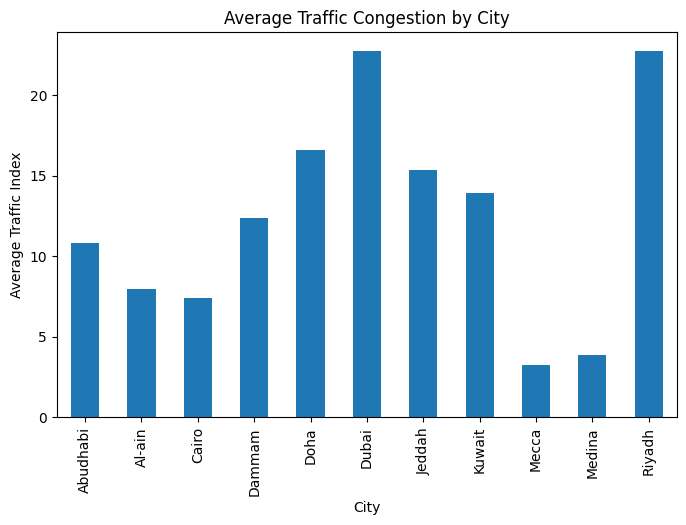


Average Traffic Congestion by City:
City
Riyadh      22.776613
Dubai       22.770873
Doha        16.618386
Jeddah      15.374741
Kuwait      13.898181
Dammam      12.403986
Abudhabi    10.843944
Al-ain       7.953416
Cairo        7.408109
Medina       3.879917
Mecca        3.225932
Name: TrafficIndexLive, dtype: float64


In [60]:
df.groupby("City")["TrafficIndexLive"].mean().plot(kind="bar", figsize=(8,5))

plt.title("Average Traffic Congestion by City")
plt.xlabel("City")
plt.ylabel("Average Traffic Index")
plt.show()
avg_city_traffic = df.groupby("City")["TrafficIndexLive"].mean().sort_values(ascending=False)
print("\nAverage Traffic Congestion by City:")
print(avg_city_traffic)

### Insight
This chart compares the average traffic congestion level across cities.  
Cities with higher average traffic index values experience heavier congestion than others.

## Question 2: At what time of day is traffic congestion the highest?

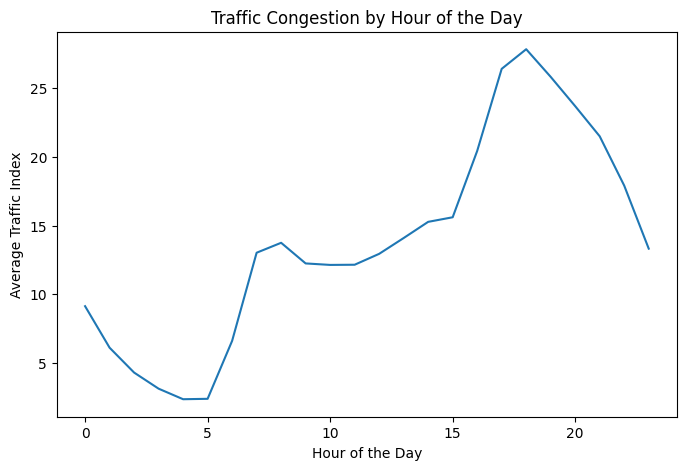

Peak hour: 18
Average traffic index at peak hour: 27.84021406727829


In [61]:
df.groupby("Hour")["TrafficIndexLive"].mean().plot(figsize=(8,5))

plt.title("Traffic Congestion by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Traffic Index")
plt.show()
peak_hour = df.groupby("Hour")["TrafficIndexLive"].mean().idxmax()
peak_value = df.groupby("Hour")["TrafficIndexLive"].mean().max()

print("Peak hour:", peak_hour)
print("Average traffic index at peak hour:", peak_value)

### Insight
Traffic congestion changes during the day and tends to increase during rush hours.  
This helps identify the peak traffic periods.

## Question 3: Does higher traffic congestion lead to longer travel times?

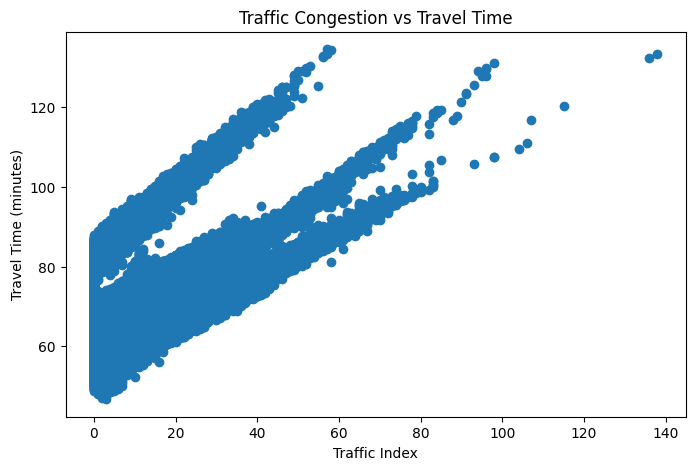

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(df["TrafficIndexLive"], df["TravelTimeLive"])

plt.title("Traffic Congestion vs Travel Time")
plt.xlabel("Traffic Index")
plt.ylabel("Travel Time (minutes)")
plt.show()


### Insight
The scatter plot shows the relationship between congestion and travel time.  
In general, higher traffic congestion is associated with longer travel times.

## Question 4: Do more traffic jams lead to longer congestion?

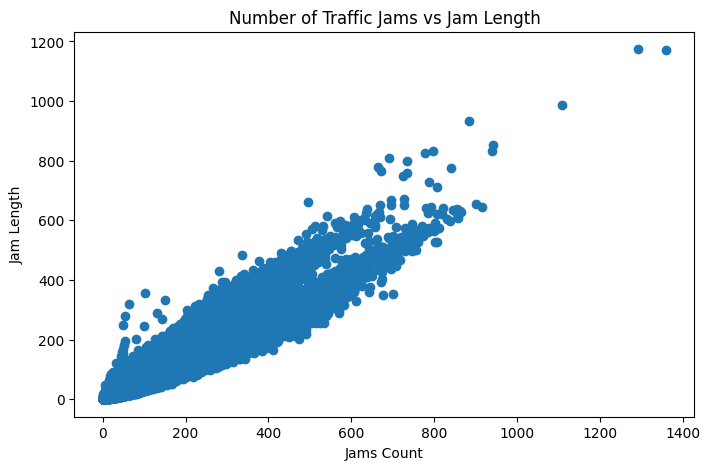

In [63]:
plt.figure(figsize=(8,5))
plt.scatter(df["JamsCount"], df["JamsLength"])

plt.title("Number of Traffic Jams vs Jam Length")
plt.xlabel("Jams Count")
plt.ylabel("Jam Length")
plt.show()

### Insight
This plot examines whether a higher number of traffic jams is associated with longer congestion on the roads.  
The pattern suggests that more traffic jams generally lead to longer jam length.

## Question 5: Which variables are most related to traffic congestion?

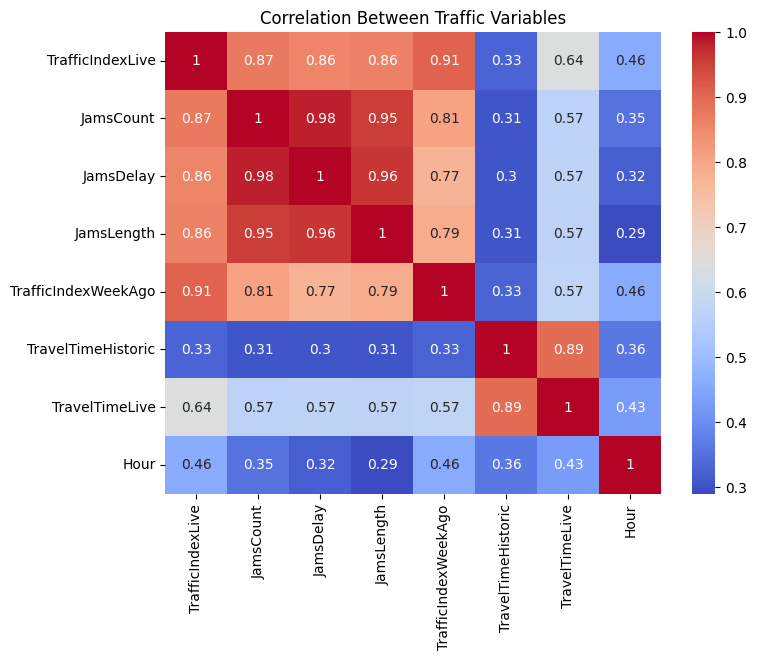


Correlation with TrafficIndexLive:
TrafficIndexLive       1.000000
TrafficIndexWeekAgo    0.906485
JamsCount              0.873597
JamsLength             0.863189
JamsDelay              0.857590
TravelTimeLive         0.642326
Hour                   0.456505
TravelTimeHistoric     0.331072
Name: TrafficIndexLive, dtype: float64


In [64]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Between Traffic Variables")
plt.show()
corr = df.corr(numeric_only=True)

print("\nCorrelation with TrafficIndexLive:")
print(corr["TrafficIndexLive"].sort_values(ascending=False))

### Insight
The heatmap reveals strong positive relationships between:
- JamsCount and JamsDelay
- JamsCount and JamsLength
- TrafficIndexLive and ExtraTime

This means that heavier congestion is strongly associated with more jams, longer jam length, and more travel delay.

## Question 6: What is the overall distribution of traffic congestion levels?

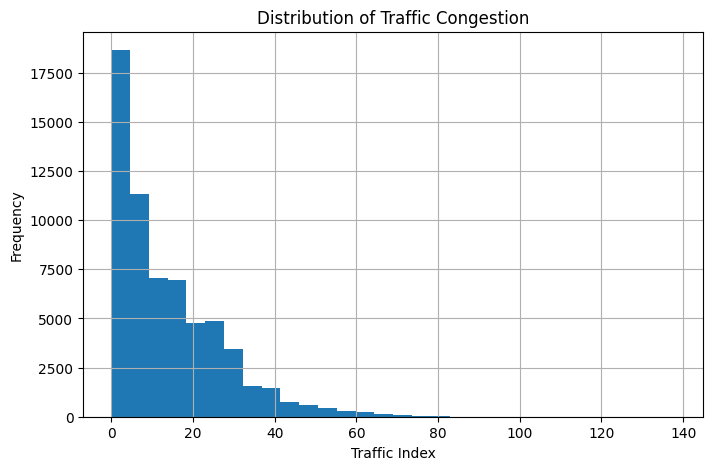

In [65]:
plt.figure(figsize=(8,5))
df["TrafficIndexLive"].hist(bins=30)

plt.title("Distribution of Traffic Congestion")
plt.xlabel("Traffic Index")
plt.ylabel("Frequency")
plt.show()

### Insight
This histogram shows how traffic congestion values are distributed across the dataset.  
It helps identify whether traffic is usually low, moderate, or high.

# 8. Final Insights

The analysis led to the following key findings:

1. Traffic congestion varies across  cities, with some cities showing higher average congestion than others.
2. Traffic congestion changes throughout the day and becomes higher during peak hours.
3. Higher traffic congestion generally leads to longer travel times.
4. A greater number of traffic jams is strongly associated with longer jam length and greater delay.
5. Traffic variables are strongly connected, especially traffic jams, delay, and congestion level.

# 9. Conclusion

This project explored traffic congestion patterns in cities using traffic index data.  
The results showed that congestion affects travel time and is strongly linked to the number and size of traffic jams.  
The analysis also highlighted daily traffic patterns and differences between cities.

Overall, the dataset provides useful insights for understanding traffic behavior and could support future traffic planning and smarter transportation analysis.